<h1>Проект: Принятие решений в бизнесе.</h1>

Я - аналитик в крупном интернет-магазине.  
Совместно с отделом маркетинга мы подготовили список гипотез для увеличения выручки нашего интернет-магазина.  

<u>Цель:</u> приоритизация гипотез и запуск А/В теста, анализ результата.

<h1>Оглавление:</h1>

[Часть 1. Приортизация гипотез.](#part_1)  
      [1.1. Применение фреймворка ICE для приоритизации гипотез. Сортировка их по убыванию приоритета.](#ICE)  
          [1.2. Применение фреймворка RICE для приоритизации гипотез. Сортировка их по убыванию приоритета.](#RICE)  
              [1.3. Изменения приоритизация гипотез при применении RICE вместо ICE. Объяснение.](#ICE_RICE)  
              
<u>Данные для первой части:</u>  

<b>Файл /datasets/hypothesis.csv.</b>  
Hypothesis — краткое описание гипотезы;  
Reach — охват пользователей по 10-балльной шкале;  
Impact — влияние на пользователей по 10-балльной шкале;  
Confidence — уверенность в гипотезе по 10-балльной шкале;  
Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.  

[Часть 2. Анализ А/В теста.](#part_2)  
    [2.1. Построение графика кумулятивной выручки по группам. Выводы и предположения.](#2.1)  
    [2.2. Построение графика кумулятивного среднего чека по группам. Выводы и предположения.](#2.2)  
    [2.3. Построение графика относительного изменения кумулятивного среднего чека группы B к группе A. Выводы и предположения.](#2.3)  
    [2.4. Построение графика кумулятивного среднего количества заказов на посетителя (конверсия) по группам. Выводы и предположения.](#2.4)  
    [2.5. Построение графика относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Выводы и предположения.](#2.5)  
    [2.6. Построение точечного графика количества заказов по пользователям. Выводы и предположения.](#2.6)  
    [2.7. Подсчет 95-го и 99-го перцентилей количества заказов на пользователя. Выбор границы для определения аномальных пользователей.](#2.7)  
    [2.8. Построение точечного графика стоимостей заказов. Выводы и предположения.](#2.8)  
    [2.9. Подсчет 95-го и 99-го перцентилей стоимости заказов. Выбор границы для определения аномальных заказов.](#2.9)  
    [2.10. Подсчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Выводы и предположения.](#2.10)  
    [2.11. Подсчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным. Выводы и предположения.](#2.11)  
    [2.12. Подсчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Выводы и предположения.](#2.12)  
    [2.13. Подсчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным. Выводы и предположения.](#2.13)  
    [2.14. Принятие решения по результатам теста и объяснение его. Варианты решений:  
    1. Остановить тест, зафиксировать победу одной из групп.  
2. Остановить тест, зафиксировать отсутствие различий между группами.  
3. Продолжить тест.](#2.14)  
        
<u>Данные для второй части:</u>  
        
<b>Файл /datasets/orders.csv.</b>  
transactionId — идентификатор заказа;  
visitorId — идентификатор пользователя, совершившего заказ;  
date — дата, когда был совершён заказ;  
revenue — выручка заказа;  
group — группа A/B-теста, в которую попал заказ.  
        
<b>Файл /datasets/visitors.csv.</b>  
date — дата;  
group — группа A/B-теста;  
visitors — количество пользователей в указанную дату в указанной группе A/B-теста  
    

<h1>Часть 1. Приоритизация гипотез.</h1>
<a id='part_1'></a>

In [1]:
# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy import stats as st
import math
import numpy as np

In [2]:
# загрузим наши файлы
hypothesis = pd.read_csv('/datasets/hypothesis.csv')
orders = pd.read_csv('/datasets/orders.csv')
visitors = pd.read_csv('/datasets/visitors.csv')

In [3]:
# нужно, чтобы отображались все колонки в дальнейшем
pd.set_option('display.max_columns', None)

In [4]:
# добавим функцию для оптимизации
def check_df (df):
    display(df.info()) # общая информация 
    display(df.head()) # первые 5 строк
    display(df.isna().sum()) # пропуски
    display(df.duplicated().sum()) # дубликаты

In [5]:
# посмотрим наши файлы
check_df(hypothesis)
check_df(orders)
check_df(visitors)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


None

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1


Hypothesis    0
Reach         0
Impact        0
Confidence    0
Efforts       0
dtype: int64

0

...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


None

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


date        0
group       0
visitors    0
dtype: int64

0

В целом все хорошо, за исключением столбца 'date' в файлах 'orders' и 'visitors'. Там неверный тип данных.

In [6]:
# поменяем тип данных на верный
orders['date'] = pd.to_datetime(orders['date'])
visitors['date'] = pd.to_datetime(visitors['date'])

In [7]:
# проверим
orders.info()
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   int64         
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


<b>1.1. Применение фреймворка ICE для приоритизации гипотез. Сортировка их по убыванию приоритета.</b>
<a id='ICE'></a>

In [8]:
# отобразим полностью название гипотез
pd.options.display.max_colwidth = 210

In [9]:
# а также округлим данные с типом 'float' до 2-х знаков
pd.options.display.float_format = '{:,.2f}'.format

In [10]:
# применим фреймворк ICE
hypothesis['ICE'] = hypothesis['Impact'] * hypothesis['Confidence'] / hypothesis['Efforts']

In [11]:
# отсортируем по убыванию приоритета и посмотрим
hypothesis.sort_values('ICE', ascending=False)

,Hypothesis,Reach,Impact,Confidence,Efforts,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


<Figure size 720x432 with 0 Axes>

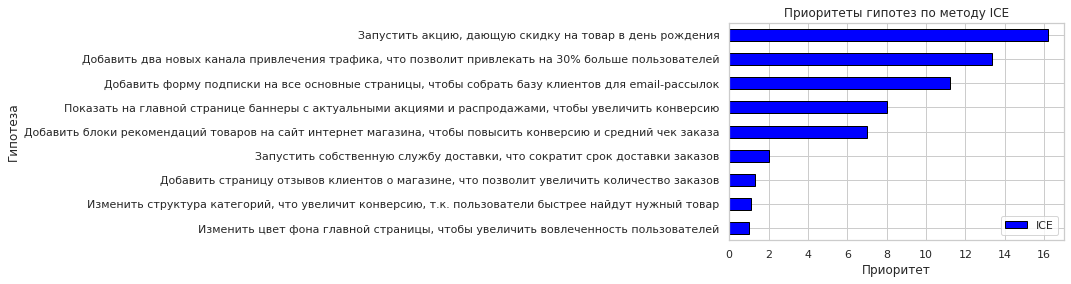

In [12]:
# для наглядности построим график

sns.set(style="whitegrid")  # зададим белый фон с сеткой
plt.figure(figsize=(10, 6))  # зададим фигуру с размерами

# выберем столбцы, установим столбец в качестве индекса и отсортируем
ax = hypothesis[['Hypothesis', 'ICE']] \
    .set_index('Hypothesis') \
    .sort_values('ICE', ascending=True) \
    .plot(
        kind='barh',  # горизонтальный график 
        color='blue',  # синий цвет
        edgecolor='black'  # черные границы
    )

# настроим оси и название
ax.set_xlabel('Приоритет')
ax.set_ylabel('Гипотеза')
ax.set_title('Приоритеты гипотез по методу ICE')

# добавим сетку
ax.xaxis.grid(True)

# посмотрим график
plt.show()

<b>1.2. Применение фреймворка RICE для приоритизации гипотез. Сортировка их по убыванию приоритета.</b>
<a id='RICE'></a>

In [13]:
# применим фреймворк RICE
hypothesis['RICE'] = hypothesis['Reach'] * hypothesis['Impact'] * hypothesis['Confidence'] / hypothesis['Efforts']

In [14]:
# отсортируем по убыванию приоритета и посмотрим
hypothesis.sort_values('RICE', ascending=False)

,Hypothesis,Reach,Impact,Confidence,Efforts,ICE,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.00,56.00
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.00
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.00,40.00
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.20
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.00
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.00


<Figure size 720x432 with 0 Axes>

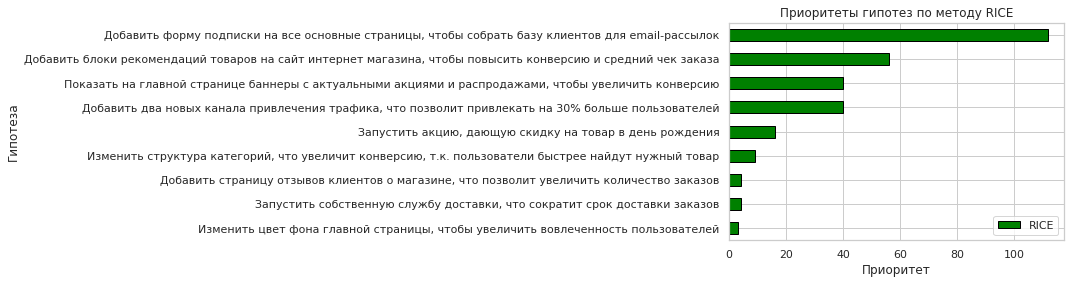

In [15]:
# для наглядности построим график

sns.set(style="whitegrid")  # зададим белый фон с сеткой
plt.figure(figsize=(10, 6))  # зададим фигуру с размерами

# выберем столбцы, установим столбец в качестве индекса и отсортируем
ax = hypothesis[['Hypothesis', 'RICE']] \
    .set_index('Hypothesis') \
    .sort_values('RICE', ascending=True) \
    .plot(
        kind='barh',  # горизонтальный график 
        color='green',  # зеленый цвет
        edgecolor='black'  # черные границы
    )

# настроим оси и название
ax.set_xlabel('Приоритет')
ax.set_ylabel('Гипотеза')
ax.set_title('Приоритеты гипотез по методу RICE')

# добавим сетку
ax.xaxis.grid(True)

# посмотрим график
plt.show()

<b>1.3. Изменения приоритизация гипотез при применении RICE вместо ICE. Объяснение.</b>
<a id='ICE_RICE'></a>

In [16]:
ICE_hypothesis = hypothesis.sort_values('ICE', ascending=False).iloc[:, [0, -2]]
RICE_hypothesis = hypothesis.sort_values('RICE', ascending=False).iloc[:, [0, -1]]

In [17]:
ICE_hypothesis

,Hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


In [18]:
RICE_hypothesis

,Hypothesis,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.00
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.00
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.00
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.00
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.00


<i>Объяснение:</i>  
При применении метода RICE (Reach, Impact, Confidence, Efforts) вместо ICE (Impact, Confidence, Efforts) приоритизация гипотез изменилась, поскольку RICE учитывает не только влияние и уверенность, но и охват (Reach), что позволяет более точно оценить потенциальную ценность каждой гипотезы.

<h1>Часть 2. Анализ А/В теста.</h1>
<a id='part_2'></a>

<b>Осуществим проверку имеющихся у нас данных для возможности реализации анализа А/В теста.</b>

In [19]:
# проверим уникальные группы в заказах
orders['group'].unique()

array(['B', 'A'], dtype=object)

In [20]:
# теперь в пользователях
visitors['group'].unique()

array(['A', 'B'], dtype=object)

<i>В каждом нашем файле по 2 унивальные группы А и В.</i>

In [21]:
# проверим период теста в заказах
orders['date'].min()

Timestamp('2019-08-01 00:00:00')

In [22]:
orders['date'].max()

Timestamp('2019-08-31 00:00:00')

In [23]:
# и период у пользователей
visitors['date'].min()

Timestamp('2019-08-01 00:00:00')

In [24]:
visitors['date'].max()

Timestamp('2019-08-31 00:00:00')

<i>Периоды проведения теста в обоих наших файлах совпадают (с 01 августа 2019 г. по 31 августа 2019 г.)</i>

In [25]:
# теперь посмотрим на разпределение количества пользователей в каждой группе
# посмотрим количество уникальных пользователей в каждой группе заказов
orders.groupby('group')['visitorId'].nunique()

group
A    503
B    586
Name: visitorId, dtype: int64

In [26]:
# теперь количество уникальных пользователей в каждой группе пользователей
visitors.groupby('group')['visitors'].sum()

group
A    18736
B    18916
Name: visitors, dtype: int64

In [27]:
# и проверим пересечение пользователей между группами
group_users_A = set(orders[orders['group'] == 'A']['visitorId'])
group_users_B = set(orders[orders['group'] == 'B']['visitorId'])
len(group_users_A.intersection(group_users_B))

58

<i>у нас получилось 58 пересекающих пользователей между группами.</i>

<u>Подытожим:</u>  
- в наших файлах 'orders' и 'visitors' по 2 группы: А и В;  
- период теста в наших файлах совпадают: с 01 августа 2019 г. по 31 августа 2019 г.;
- количества пользователей в каждой группе файлов нас удолетворяют, так же выявлено пересечение пользователей между группами в количестве 58 человек.

<b>Данные подходят для проведения А/В теста. Анализировать данные будем с пересекающимися пользователями, т.к. можно будет посмотреть, как такие пользователи влияют на результаты. Если что, уберем их потом</b>

In [28]:
# подготовимся к анализу
# посмотрим еще раз 'orders'
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [29]:
# и 'visitors'
visitors.head()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [30]:
# сгруппируем заказы по дате и группе
orders_grouped = (orders.groupby(['date', 'group'], as_index=False)
                  .agg({'transactionId': 'nunique', 'visitorId': 'nunique', 'revenue': 'sum'})) 
                    # количество уникальных идентификаторов заказов
                    # количество уникальнывх идентификаторов пользователей, совершивших заказ
                    # общая выручка

# создадим копию заказов группы, индексируем данные по дате и группе
orders_grouped['group_copy'] = orders_grouped['group']
orders_grouped = orders_grouped.set_index(['date', 'group'])
# вычислим кумулятивные суммы для заказов, покупателей и выручки по каждой группе.
orders_cumsum = orders_grouped.sort_values(['date', 'group']).groupby('group_copy').cumsum().reset_index()

# теперь данные посетителей сгруппируем по дате и группе
visitors_cumsum = visitors.groupby(['date', 'group'], as_index=False).agg({'visitors': 'sum'}).sort_values(['date', 'group'])
visitors_cumsum['group_copy'] = visitors_cumsum['group']
# вычислим кумулятивные суммы по количеству посетителей
visitors_cumsum = visitors_cumsum.set_index(['date', 'group']).groupby('group_copy').cumsum().reset_index()

# объединим все в один датафрейм
cummulative = orders_cumsum.merge(visitors_cumsum[['date', 'group', 'visitors']], 
                                   on=['date', 'group'], 
                                   how='left')

# рассчитаем средний чек и конверсию
cummulative['average_check'] = (cummulative['revenue'] / cummulative['transactionId'])
cummulative['conversion'] = (cummulative['transactionId'] / cummulative['visitors'])

In [31]:
# посмотрим
cummulative.head()

,date,group,transactionId,visitorId,revenue,visitors,average_check,conversion
0,2019-08-01,A,24,20,148579,719,"6,190.79",0.03
1,2019-08-01,B,21,20,101217,713,"4,819.86",0.03
2,2019-08-02,A,44,39,242401,1338,"5,509.11",0.03
3,2019-08-02,B,45,43,266748,1294,"5,927.73",0.03
4,2019-08-03,A,68,63,354874,1845,"5,218.74",0.04


<b>2.1. Построение графика кумулятивной выручки по группам. Выводы и предположения.</b>
<a id='2.1'></a>

In [32]:
# датафрейм с кумулятивной выручкой по дням в группе А
revenueCummulativeA = cummulative[cummulative['group']=='A'][['date','revenue']]
# датафрейм с кумулятивной выручкой по дням в группе B
revenueCummulativeB = cummulative[cummulative['group']=='B'][['date','revenue']]

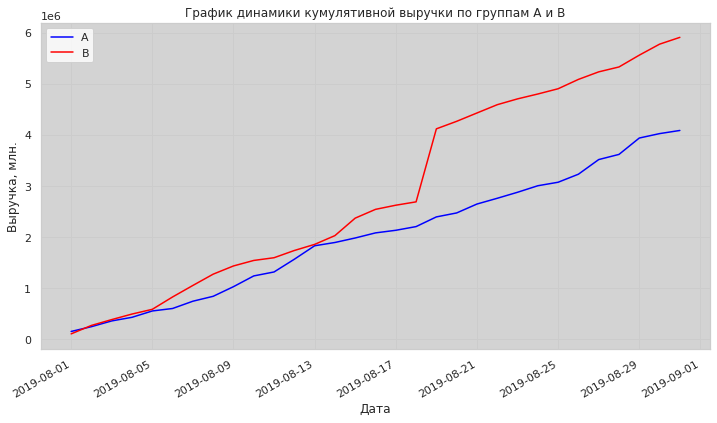

In [33]:
# построим график
plt.figure(figsize=(12, 6))
plt.plot(revenueCummulativeA['date'], revenueCummulativeA['revenue'], label='A', color='blue')
plt.plot(revenueCummulativeB['date'], revenueCummulativeB['revenue'], label='B', color='red')

plt.title('График динамики кумулятивной выручки по группам А и В')
plt.ylabel('Выручка, млн.')
plt.xlabel('Дата')
plt.xticks(rotation=30, ha='right')
plt.grid(True)
plt.gca().set_facecolor('lightgray')
plt.legend(loc='upper left')

plt.show()

<i>Выводы и предположения:</i>  

Кумулятивная выручка группы А растет линейно.  
Кумулятивная выручка группы А меньше, чем у группы В.  
У кумулятивной выручки группы В наблюдаем резкий скачок в промежутке с 17 по 21 августа 2019 г.

Возможно такой выброс произошел из-за большого количества заказов за этот период.

<b>2.2. Построение графика кумулятивного среднего чека по группам. Выводы и предположения.</b>
<a id='2.2'></a>

In [34]:
# датафрейм с кумулятивным средним чеком по дням в группе А
average_checkCummulativeA = cummulative[cummulative['group']=='A'][['date','average_check']]
# датафрейм с кумулятивным средним чеком по дням в группе B
average_checkCummulativeB = cummulative[cummulative['group']=='B'][['date','average_check']]

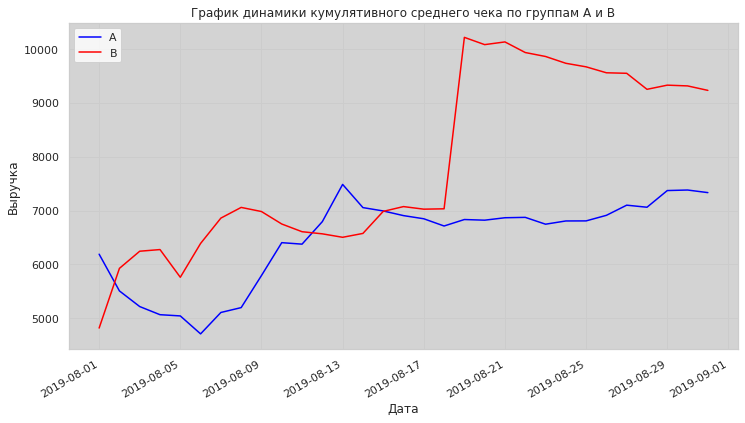

In [35]:
# построим график
plt.figure(figsize=(12, 6))
plt.plot(average_checkCummulativeA['date'], average_checkCummulativeA['average_check'], label='A', color='blue')
plt.plot(average_checkCummulativeB['date'], average_checkCummulativeB['average_check'], label='B', color='red')

plt.title('График динамики кумулятивного среднего чека по группам А и В')
plt.ylabel('Выручка')
plt.xlabel('Дата')
plt.xticks(rotation=30, ha='right')
plt.grid(True)
plt.gca().set_facecolor('lightgray')
plt.legend(loc='upper left')

plt.show()

<i>Выводы и предположения:</i>  

Кумулятивный средний чек группы А со временем стабилизируется.  
Кумулятивный средний чек группы В опять делает скачок в промежутке от 17 до 21 августа 2019 г.  

Возможно в этот период пользователи совершали дорогстоющие покупки.

<b>2.3. Построение графика относительного изменения кумулятивного среднего чека группы B к группе A. Выводы и предположения.</b>
<a id='2.3'></a>

In [36]:
# объединим таблицы обеих групп в 'average_checkCummulativeA_B', чтобы у нас были даты и средние чеки групп А и В
average_checkCummulativeA_B = (average_checkCummulativeA[['date', 'average_check']].merge(
    average_checkCummulativeB[['date', 'average_check']],
    left_on='date', 
    right_on='date', 
    how='left', 
    suffixes=['_A', '_B'])
)

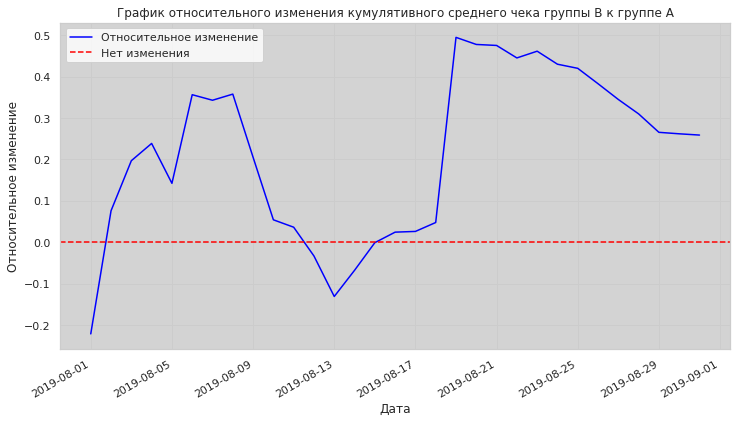

In [37]:
# построим график
plt.figure(figsize=(12, 6))  
plt.plot(average_checkCummulativeA_B['date'], 
         average_checkCummulativeA_B['average_check_B'] / average_checkCummulativeA_B['average_check_A'] - 1, 
         color='blue', label='Относительное изменение')

plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Относительное изменение')


plt.axhline(y=0, color='red', linestyle='--', label='Нет изменения')

plt.xticks(rotation=30, ha='right')
plt.grid(True)
plt.gca().set_facecolor('lightgray')
plt.legend(loc='upper left')

plt.show()

<i>Выводы и предположения:</i>  

На графике видим резкие скачки в разных местах.  

Но опять же, могут быть выбросы, или же крупные дорогстоющие заказы.

<b>2.4. Построение графика кумулятивного среднего количества заказов на посетителя (конверсия) по группам. Выводы и предположения.</b>
<a id='2.4'></a>

In [38]:
# датафрейм с кумулятивной конверсией по дням в группе А
conversionCummulativeA = cummulative[cummulative['group']=='A'][['date','conversion']]
# датафрейм с кумулятивной конверсией по дням в группе B
conversionCummulativeB = cummulative[cummulative['group']=='B'][['date','conversion']]

In [39]:
cummulative

,date,group,transactionId,visitorId,revenue,visitors,average_check,conversion
0,2019-08-01,A,24,20,148579,719,"6,190.79",0.03
1,2019-08-01,B,21,20,101217,713,"4,819.86",0.03
2,2019-08-02,A,44,39,242401,1338,"5,509.11",0.03
3,2019-08-02,B,45,43,266748,1294,"5,927.73",0.03
4,2019-08-03,A,68,63,354874,1845,"5,218.74",0.04
...,...,...,...,...,...,...,...,...
57,2019-08-29,B,596,584,5559398,17708,"9,327.85",0.03
58,2019-08-30,A,545,531,4022970,18037,"7,381.60",0.03
59,2019-08-30,B,620,608,5774631,18198,"9,313.92",0.03
60,2019-08-31,A,557,543,4084803,18736,"7,333.58",0.03


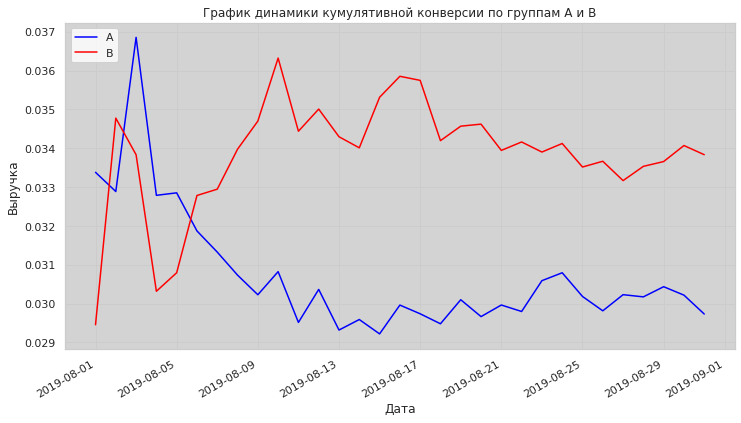

In [40]:
# построим график
plt.figure(figsize=(12, 6))
plt.plot(conversionCummulativeA['date'], conversionCummulativeA['conversion'], label='A', color='blue')
plt.plot(conversionCummulativeB['date'], conversionCummulativeB['conversion'], label='B', color='red')

plt.title('График динамики кумулятивной конверсии по группам А и В')
plt.ylabel('Выручка')
plt.xlabel('Дата')
plt.xticks(rotation=30, ha='right')
plt.grid(True)
plt.gca().set_facecolor('lightgray')
plt.legend(loc='upper left')

plt.show()

<i>Выводы и предположения:</i>  

Конверсии обеих групп в начале сильно клеблются, после чего выравниваются.  
В начале можем видеть резкие скачки конверсии как группы А так и группы В.  
После этих скачков конверсия идет на спад в обеих группах, но конверсия группы В значительно прельщает нежели конверсия группы А. 

<b>2.5. Построение графика относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. Выводы и предположения.</b>
<a id='2.5'></a>

In [41]:
# объединим таблицы обеих групп в 'conversionCummulativeA_B', чтобы у нас были даты и конверсия групп А и В
conversionCummulativeA_B = (conversionCummulativeA[['date', 'conversion']].merge(
    conversionCummulativeB[['date', 'conversion']], 
    on='date', 
    how='left', 
    suffixes=['_A', '_B'])
)

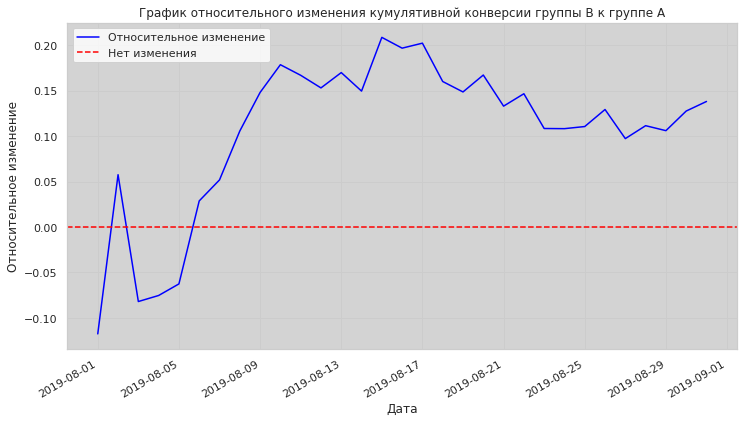

In [42]:
# построим график
plt.figure(figsize=(12, 6))  
plt.plot(conversionCummulativeA_B['date'], 
         conversionCummulativeA_B['conversion_B'] / conversionCummulativeA_B['conversion_A'] - 1, 
         color='blue', label='Относительное изменение')

plt.title('График относительного изменения кумулятивной конверсии группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Относительное изменение')


plt.axhline(y=0, color='red', linestyle='--', label='Нет изменения')

plt.xticks(rotation=30, ha='right')
plt.grid(True)
plt.gca().set_facecolor('lightgray')
plt.legend(loc='upper left')

plt.show()

<i>Выводы и предположения:</i>  

В начале конверсия группы В проигрывала группе А.  
Но затем вырвалась вперед.

<b>2.6. Построение точечного графика количества заказов по пользователям. Выводы и предположения.</b>
<a id='2.6'></a>

In [43]:
# группируем данные в 'orders' по столбцу 'visitorId' и считаем количество их уникальных значений 'transactionId' для столбца
orders_by_users = orders.groupby('visitorId', as_index=False).agg({'transactionId':'nunique'})

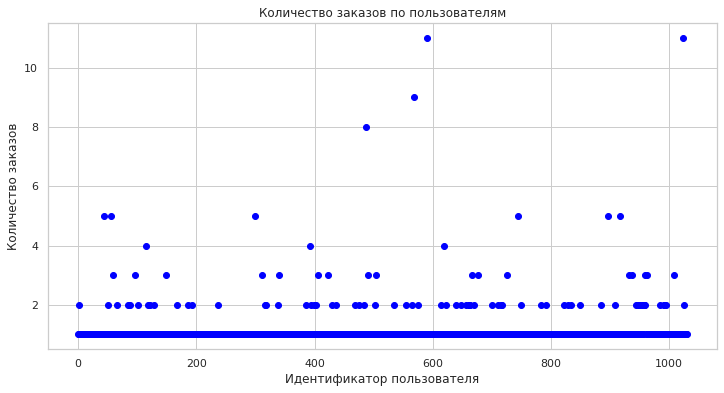

In [44]:
# построим график
x_values = pd.Series(range(0, len(orders_by_users['transactionId'])))

plt.figure(figsize=(12, 6))
plt.scatter(x_values, orders_by_users['transactionId'], color='blue')

plt.title('Количество заказов по пользователям')
plt.xlabel('Идентификатор пользователя')
plt.ylabel('Количество заказов')

plt.grid(True)

plt.show()

<i>Выводы и предположения:</i>  

В основном пользователи совершает по одной покупке (заказу).  
Так же много пользователей которые совершили по 2-3 покупки (заказа).  

<b>2.7. Подсчет 95-го и 99-го перцентилей количества заказов на пользователя. Выбор границы для определения аномальных пользователей.</b>
<a id='2.7'></a>

In [45]:
# посчитаем перцентили 95
np.percentile(orders_by_users['transactionId'], [95])

array([2.])

In [46]:
# посчитаем перцентили 99
np.percentile(orders_by_users['transactionId'], [99])

array([4.])

Всего лишь не более 5% пользователей совершали более 2-х покупок (заказов).  
1% пользователей совершал более 4-х покупок (заказов).  
Выберем границу <b>4 заказа на одного пользователя</b> для определения аномалий.

In [47]:
# создадим список для дальнейшего исследования
emissions = orders_by_users[orders_by_users['transactionId'] >= 4]['visitorId'].to_list()

<b>2.8. Построение точечного графика стоимостей заказов. Выводы и предположения.</b>
<a id='2.8'></a>

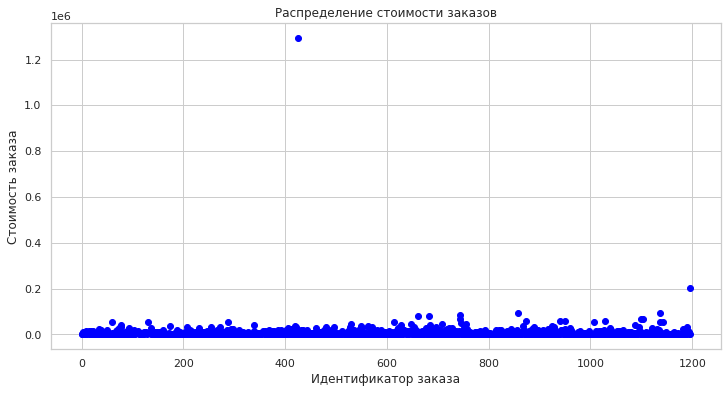

In [48]:
# построим график
x_values = pd.Series(range(0, len(orders['revenue'])))

plt.figure(figsize=(12, 6))

plt.scatter(x_values, orders['revenue'], color='blue')

plt.title('Распределение стоимости заказов')
plt.xlabel('Идентификатор заказа')
plt.ylabel('Стоимость заказа')

plt.grid(True)

plt.show()

На графике отчетливо видим 2 выброса.  
Такое может сильно повлиять на исследование.  
Лучше посмотрим график без этих выбросов.

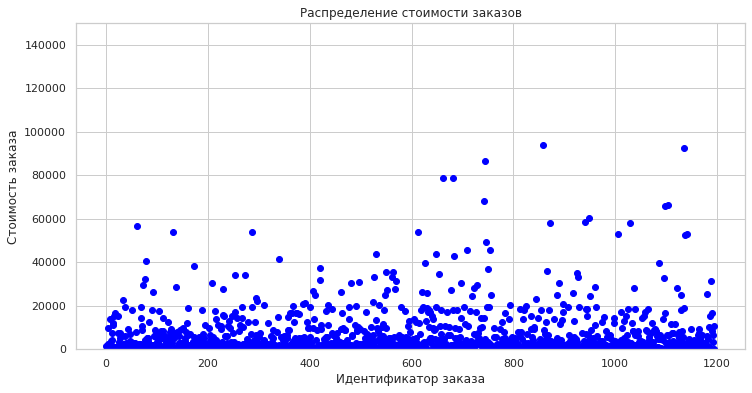

In [49]:
# построим график без выбросов
x_values = pd.Series(range(0, len(orders['revenue'])))

plt.figure(figsize=(12, 6))

plt.scatter(x_values, orders['revenue'], color='blue')
plt.ylim(0, 150000)

# Добавление заголовка и меток осей
plt.title('Распределение стоимости заказов')
plt.xlabel('Идентификатор заказа')
plt.ylabel('Стоимость заказа')

plt.grid(True)

plt.show()

<i>Выводы и предположения:</i>  
    
В основном пользователи заказывают до 20.000.

<b>2.9. Подсчет 95-го и 99-го перцентилей стоимости заказов. Выбор границы для определения аномальных заказов.</b>
<a id='2.9'></a>

In [50]:
np.percentile(orders['revenue'], [95])

array([28000.])

In [51]:
np.percentile(orders['revenue'], [99])

array([58233.2])

Выбираем границу <b>58233.2</b> (по величине 99 перецентиля) для определения аномальных заказов.

<b>2.10. Подсчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным. Выводы и предположения.</b>
<a id='2.10'></a>

In [52]:
# сгруппируем и агрегируем данные о заказах
orders_agg = orders.groupby('group').agg({'transactionId': 'count'})
# сгруппируем и агрегируем данные о пользователях
visitors_agg = visitors.groupby('group').agg({'visitors': 'sum'})
# объединим полученные данные
conversion = orders_agg.join(visitors_agg).reset_index()
# и рассчитаем коэффицент конверсии
conversion['conversion'] = conversion['transactionId'] / conversion['visitors']

<b>В данном случае будем использовать Z-тест для пропорций.</b>  
Z-тест для пропорций позволяет оценить, есть ли статистически значимая разница между этими двумя пропорциями + наши выборки достаточно велики для надежности нашего результа.

<i>Основная и альтернативная гипотезы:</i>  
    
<b>Н0:</b> Конверсии в группе А и группе В равны  
<b>Н1:</b> Конверсии в группе А и в группе В не равны

In [53]:
# проведем статистический Z-тест для сравнения
alpha = 0.05

purchases = np.array(conversion['transactionId'])
leads = np.array(conversion['visitors'])

p1 = purchases[0] / leads[0]
p2 = purchases[1] / leads[1]

combined = (purchases.sum()) / (leads.sum())

difference = p1 - p2
z_value = difference / np.sqrt(combined * (1 - combined) * (1 / leads[0] + 1 / leads[1]))
p_value = 2 * (1 - st.norm.cdf(abs(z_value)))

relative_increase = ((p2 - p1) / p1) * 100

print(f'Конверсия группы A: {p1:.4f}')
print(f'Конверсия группы B: {p2:.4f}')
print(f'Z-значение: {z_value:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'Относительный прирост конверсии группы B к конверсии группы A: {relative_increase:.2f}%')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу, конверсии в группах не равны")
else:
    print("Не получилось отвергнуть нулевую гипотезу, конверсии в группах равны")

Конверсия группы A: 0.0297
Конверсия группы B: 0.0338
Z-значение: -2.2700
p-значение: 0.0232
Относительный прирост конверсии группы B к конверсии группы A: 13.81%
Отвергаем нулевую гипотезу, конверсии в группах не равны


<i>Выводы и предположения:</i>  

По "сырым" данным делаем вывод, что различия в конверсии в группе А и группе В есть.  
В группе В конверсия больше.  
Относительный прирост группы В составляет 13.81%.

Статистическая значимость есть.

<b>2.11. Подсчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным. Выводы и предположения.</b>
<a id='2.11'></a>

<b>В данном случае будем использовать критерий Манна-Уитни.</b>  
Критерий Манна-Уитни не требует, чтобы данные следовали нормальному распределению (то есть идеально для данных с выбросами или же с ненормальным распределением), позволяет сравнивать 2 независимые группы по количественному показателю.

<i>Основная и альтернативная гипотезы:</i>  
    
<b>Н0:</b> Средние чеки в группе А и группе В равны  
<b>Н1:</b> Средние в группе А и в группе В не равны

In [54]:
# воспользуемся критерием Манна-Уитни
alpha = 0.05

mean_revenue_A = orders[orders['group'] == 'A']['revenue'].mean()
mean_revenue_B = orders[orders['group'] == 'B']['revenue'].mean()

results = st.mannwhitneyu(orders[orders['group'] == 'A']['revenue'], 
                            orders[orders['group'] == 'B']['revenue'])

p_value = results.pvalue
u_statistic = results.statistic

relative_increase = ((mean_revenue_B - mean_revenue_A) / mean_revenue_A) * 100

print(f'Средний чек группы A: {mean_revenue_A:.4f}')
print(f'Средний чек группы B: {mean_revenue_B:.4f}')
print(f'U-статистика: {u_statistic:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'Относительный прирост среднего чека группы B к группе A: {relative_increase:.2f}%')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу, средние чеки в группах не равны")
else:
    print("Не получилось отвергнуть нулевую гипотезу, средние чеки в группах равны")

Средний чек группы A: 7333.5781
Средний чек группы B: 9230.8750
U-статистика: 176175.0000
p-значение: 0.7293
Относительный прирост среднего чека группы B к группе A: 25.87%
Не получилось отвергнуть нулевую гипотезу, средние чеки в группах равны


<i>Выводы и предположения:</i>  

По "сырым" данным делаем вывод, что различия в средних чеках в группе А и группе В есть.  
В группе В средний чек больше.  
Относительный прирост группы В составляет 25.87%.

Статистическая значимость есть.

<b>2.12. Подсчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным. Выводы и предположения.</b>
<a id='2.12'></a>

In [55]:
# очистим данные
clean_orders = orders[~orders['visitorId'].isin(emissions)]

# считаем количество заказов и пользователей
conversion_clean = (clean_orders.groupby('group')
                    .agg({'transactionId': 'count'})
                    .join(visitors.groupby('group')
                          .agg({'visitors': 'sum'}))
                    .reset_index())

In [56]:
conversion_clean

,group,transactionId,visitors
0,A,517,18736
1,B,599,18916


<b>В данном случае будем использовать Z-тест для пропорций.</b>  
Z-тест для пропорций позволяет оценить, есть ли статистически значимая разница между этими двумя пропорциями + наши выборки достаточно велики для надежности нашего результа.

как и в п. 2.10

<i>Основная и альтернативная гипотезы:</i>  
    
<b>Н0:</b> Конверсии в группе А и группе В равны  
<b>Н1:</b> Конверсии в группе А и в группе В не равны

In [57]:
# проведем статистический тест для сравнения
alpha = 0.05

purchases = np.array(conversion_clean['transactionId'])
leads = np.array(conversion_clean['visitors'])

p1 = purchases[0] / leads[0]
p2 = purchases[1] / leads[1]

combined = (purchases.sum()) / (leads.sum())


difference = p1 - p2
z_value = difference / np.sqrt(combined * (1 - combined) * (1 / leads[0] + 1 / leads[1]))
p_value = 2 * (1 - st.norm.cdf(abs(z_value)))

relative_increase = ((p2 - p1) / p1) * 100

print(f'Конверсия группы A: {p1:.4f}')
print(f'Конверсия группы B: {p2:.4f}')
print(f'Z-значение: {z_value:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'Относительный прирост конверсии группы B к конверсии группы A: {relative_increase:.2f}%')
               
if p_value < alpha:
    print("Отвергаем нулевую гипотезу, конверсии в группах не равны")
else:
    print("Не получилось отвергнуть нулевую гипотезу, конверсии в группах равны")

Конверсия группы A: 0.0276
Конверсия группы B: 0.0317
Z-значение: -2.3297
p-значение: 0.0198
Относительный прирост конверсии группы B к конверсии группы A: 14.76%
Отвергаем нулевую гипотезу, конверсии в группах не равны


<i>Выводы и предположения:</i>  

По "очищенным" данным делаем вывод, что различия в конверсиях в группе А и группе В есть.  
Конверсия группы В все также привышает конверсию группы А.  
Относительный прирост группы В по очищенным данным увеличился до 14.76%.

Статистическая значимость есть.

<b>2.13. Подсчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным. Выводы и предположения.</b>
<a id='2.13'></a>

In [58]:
# очистим данные
orders_clean = orders.query('revenue <= 58233.2')

<b>В данном случае будем использовать критерий Манна-Уитни.</b>  
Критерий Манна-Уитни не требует, чтобы данные следовали нормальному распределению (то есть идеально для данных с выбросами или же с ненормальным распределением), позволяет сравнивать 2 независимые группы по количественному показателю.

как и в п. 2.11

<i>Основная и альтернативная гипотезы:</i>  
    
<b>Н0:</b> Средние чеки в группе А и группе В равны  
<b>Н1:</b> Средние в группе А и в группе В не равны

In [59]:
# воспользуемся критерием Манна-Уитни
alpha = 0.05

mean_revenue_A = orders_clean[orders_clean['group']=='A']['revenue'].mean()
mean_revenue_B = orders_clean[orders_clean['group']=='B']['revenue'].mean()

results = st.mannwhitneyu(orders_clean[orders_clean['group']=='A']['revenue'], 
                          orders_clean[orders_clean['group']=='B']['revenue'])

p_value = results.pvalue
u_statistic = results.statistic

relative_increase = ((mean_revenue_B - mean_revenue_A) / mean_revenue_A) * 100

print(f'Средний чек группы A: {mean_revenue_A:.4f}')
print(f'Средний чек группы B: {mean_revenue_B:.4f}')
print(f'U-статистика: {u_statistic:.4f}')
print(f'p-значение: {p_value:.4f}')
print(f'Относительный прирост среднего чека группы B к группе A: {relative_increase:.2f}%')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу, средние чеки в группах не равны")
else:
    print("Не получилось отвергнуть нулевую гипотезу, средние чеки в группах равны")

Средний чек группы A: 6470.5873
Средний чек группы B: 6592.6929
U-статистика: 171718.5000
p-значение: 0.6209
Относительный прирост среднего чека группы B к группе A: 1.89%
Не получилось отвергнуть нулевую гипотезу, средние чеки в группах равны


<i>Выводы и предположения:</i>  

По "очищенным" данным делаем вывод, что различия в средних чеках в группе А и группе В есть.  
В группе В средний чек чуть больше.  
Относительный прирост группы В по очищенным данным упал до 1.89%.

Статистическая значимости практически нет.

<b>2.14. Принятие решения по результатам теста и объяснение его. Варианты решений:
1. Остановить тест, зафиксировать победу одной из групп.
2. Остановить тест, зафиксировать отсутствие различий между группами.
3. Продолжить тест.</b>
<a id='2.14'></a>

- По визуализациям наглядно видим что группа А стабильно уступает группе В.

- Конверсия группы В стабильно выше конверсии группы А. По "сырым" данным около 13%, по "очищенным" - 14%. Это статистически значимое различие.

- Есть статистическое различие по средним чеким в "сырых" данных группы А и группы В. Группа В опять же лидирует. Но в "очищенных" данных нельзя сказать, что различия прям сильные.

На основе вышесказанного предлагаю 1 вариант решения: <b>Остановить тест, зафиксировав победу группы В</b>.